# CheckerboardSMC on M71 8x8 Cutouts

Run CheckerboardSMC on a single 8x8-pixel cutout from the M71 globular cluster image.
Each 8x8 cutout is split into a 2x2 grid of 4x4 tiles with padding for prior and PSF context.

In [1]:
import os
import pickle
import sys

import matplotlib.pyplot as plt
import torch

sys.path.append("/home/twhit/smcdet/")

from smcdet.checkerboard import CheckerboardSMC
from smcdet.images import M71ImageModel
from smcdet.kernel import SingleComponentMH
from smcdet.prior import M71Prior
from utils.misc import select_cuda_device

device = select_cuda_device(min_free_mb=100)
torch.cuda.set_device(device)
torch.set_default_device(device)

os.chdir(os.path.dirname(os.path.abspath("__file__")))

Selected device 0, which has 10822 MB available.


## Load data

In [2]:
with open("data/params.pkl", "rb") as f:
    params = pickle.load(f)

full_image = torch.load("data/full_image.pt").to(device)
patches = torch.load("data/patches.pt").to(device)
patch_indices = torch.load("data/patch_indices.pt")
gt_counts = torch.load("data/pruned_counts.pt", map_location="cpu")
gt_locs = torch.load("data/pruned_locs.pt", map_location="cpu")
gt_fluxes = torch.load("data/pruned_fluxes.pt", map_location="cpu")

print(f"Full image: {full_image.shape}")
print(f"Patches: {patches.shape}")
print(f"Ground truth: {gt_counts.shape[0]} tiles, count range "
      f"{gt_counts.min().int().item()}-{gt_counts.max().int().item()}")

Full image: torch.Size([320, 160])
Patches: torch.Size([332, 8, 8])
Ground truth: 332 tiles, count range 0-12


## Extract one padded cutout

Cutout 264: 4 ground truth stars
  Locs: tensor([[6.2901, 4.2669],
        [3.5062, 7.1828],
        [5.7334, 0.8309],
        [4.8895, 1.2209]])
  Fluxes: tensor([0.1188, 0.0134, 2.3878, 0.0219])
  Grid position: (33, 5)
  Padded patch: torch.Size([16, 16])


Text(0.5, 1.0, 'Padded context (16×16)')

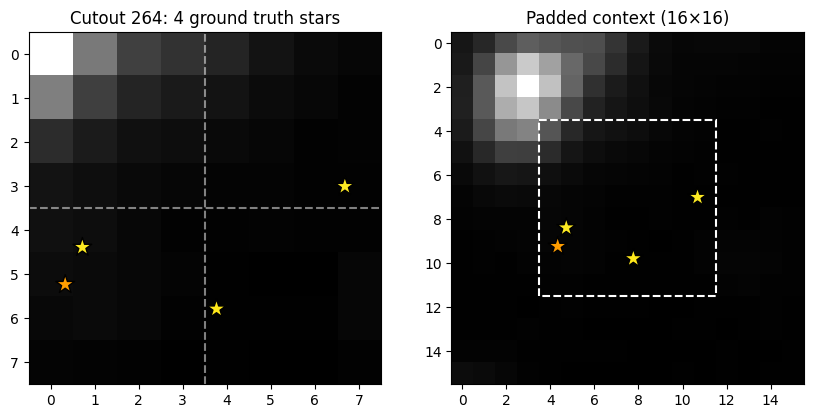

In [3]:
patch_dim = 8
image_pad = 4

# Pick a cutout with a known number of stars
cutout_idx = torch.randint(0, gt_counts.shape[0], (1,)).item()
n_true = int(gt_counts[cutout_idx].item())
true_locs = gt_locs[cutout_idx, :n_true].to(device)
true_fluxes = gt_fluxes[cutout_idx, :n_true].to(device)

print(f"Cutout {cutout_idx}: {n_true} ground truth stars")
print(f"  Locs: {true_locs.cpu()}")
print(f"  Fluxes: {true_fluxes.cpu()}")


def extract_padded_patch(full_image, row, col, patch_dim, image_pad, background):
    """Extract a patch with surrounding context from the full image."""
    H, W = full_image.shape
    h_start = row * patch_dim - image_pad
    h_end = (row + 1) * patch_dim + image_pad
    w_start = col * patch_dim - image_pad
    w_end = (col + 1) * patch_dim + image_pad

    padded = torch.full(
        (patch_dim + 2 * image_pad, patch_dim + 2 * image_pad),
        background,
        device=full_image.device,
    )

    src_h_start = max(h_start, 0)
    src_h_end = min(h_end, H)
    src_w_start = max(w_start, 0)
    src_w_end = min(w_end, W)

    dst_h_start = src_h_start - h_start
    dst_h_end = dst_h_start + (src_h_end - src_h_start)
    dst_w_start = src_w_start - w_start
    dst_w_end = dst_w_start + (src_w_end - src_w_start)

    padded[dst_h_start:dst_h_end, dst_w_start:dst_w_end] = (
        full_image[src_h_start:src_h_end, src_w_start:src_w_end]
    )
    return padded


row, col = patch_indices[cutout_idx]
patch = patches[cutout_idx]
padded_patch = extract_padded_patch(
    full_image, row.item(), col.item(),
    patch_dim, image_pad, params["background"],
)

print(f"  Grid position: ({row.item()}, {col.item()})")
print(f"  Padded patch: {padded_patch.shape}")

# Flux range for colormap
if n_true > 0:
    flux_min = true_fluxes.min().item()
    flux_max = true_fluxes.max().item()
    margin = max((flux_max - flux_min) * 0.1, 1.0)
    vmin, vmax = flux_min - margin, flux_max + margin
else:
    vmin, vmax = 0, 50

# Display both patches side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: unpadded 8x8 patch
axes[0].imshow(patch.cpu(), cmap="gray")
axes[0].scatter(
    true_locs[:, 1].cpu() - 0.5,
    true_locs[:, 0].cpu() - 0.5,
    c=true_fluxes.cpu(), cmap="Wistia", marker="*",
    edgecolors="black", s=200, vmin=vmin, vmax=vmax,
)
axes[0].axhline(y=3.5, color="white", linestyle="--", alpha=0.5)
axes[0].axvline(x=3.5, color="white", linestyle="--", alpha=0.5)
axes[0].set_title(f"Cutout {cutout_idx}: {n_true} ground truth stars")

# Right: padded 16x16 patch with rectangle showing 8x8 region
axes[1].imshow(padded_patch.cpu(), cmap="gray")
axes[1].scatter(
    true_locs[:, 1].cpu() - 0.5 + image_pad,
    true_locs[:, 0].cpu() - 0.5 + image_pad,
    c=true_fluxes.cpu(), cmap="Wistia", marker="*",
    edgecolors="black", s=200, vmin=vmin, vmax=vmax,
)
rect = plt.Rectangle(
    (image_pad - 0.5, image_pad - 0.5), patch_dim, patch_dim,
    linewidth=1.5, edgecolor="white", facecolor="none", linestyle="--",
)
axes[1].add_patch(rect)
axes[1].set_title(f"Padded context ({padded_patch.shape[0]}×{padded_patch.shape[1]})")

## Run CheckerboardSMC

In [4]:
tile_dim = 4
pad = 4
image_pad = 4
max_objects = 8
num_catalogs = 10000

torch.manual_seed(0)

checkerboard = CheckerboardSMC(
    image=patch,
    tile_dim=tile_dim,
    pad=pad,
    image_pad=image_pad,
    PriorClass=M71Prior,
    prior_kwargs=dict(
        num_objects=max_objects,
        counts_rate=params["counts_rate"],
        h_lower=0,
        h_upper=tile_dim,
        w_lower=0,
        w_upper=tile_dim,
        flux_alpha=params["flux_alpha"],
        flux_lower=params["flux_lower"],
        flux_upper=params["flux_upper"],
    ),
    ImageModelClass=M71ImageModel,
    image_model_kwargs=dict(
        background=params["background"],
        adu_per_nmgy=params["adu_per_nmgy"],
        psf_params=params["psf_params"],
        psf_radius=params["psf_radius"],
        noise_additive=params["noise_additive"],
        noise_multiplicative=params["noise_multiplicative"],
    ),
    MutationKernelClass=SingleComponentMH,
    kernel_kwargs=dict(
        num_iters=100,
        locs_stdev=0.1,
        fluxes_stdev=2.5,
        fluxes_min=params["flux_lower"],
        fluxes_max=params["flux_upper"],
    ),
    num_catalogs=num_catalogs,
    ess_threshold_prop=0.5,
    resample_method="multinomial",
    max_smc_iters=100,
    prune_flux_lower=params["flux_detection_threshold"],
    print_every=5,
)

# Override padded image with real surrounding pixels
checkerboard.padded_image = padded_patch

checkerboard.run()

Color 0: 1 tile(s) (1x1 sub-grid)
  Tile (0, 0) -> sub-grid (0, 0): prior [-4, 8] x [-4, 8], image [-4, 8] x [-4, 8]
starting...
iteration 5: temperature in [0.0, 0.0], acceptance rate in [0.56, 0.56]
iteration 10: temperature in [0.01, 0.01], acceptance rate in [0.44, 0.44]
iteration 15: temperature in [0.05, 0.05], acceptance rate in [0.4, 0.4]
iteration 20: temperature in [0.26, 0.26], acceptance rate in [0.43, 0.43]
iteration 25: temperature in [0.74, 0.74], acceptance rate in [0.29, 0.29]
done!

Color 1: 1 tile(s) (1x1 sub-grid)
  Tile (1, 0) -> sub-grid (0, 0): prior [0, 12] x [-4, 8], image [0, 12] x [-4, 8], cond sources: 8
starting...
iteration 5: temperature in [0.0, 0.0], acceptance rate in [0.49, 0.49]
iteration 10: temperature in [0.04, 0.04], acceptance rate in [0.51, 0.51]
iteration 15: temperature in [0.21, 0.21], acceptance rate in [0.33, 0.33]
iteration 20: temperature in [0.85, 0.85], acceptance rate in [0.13, 0.13]
done!

Color 2: 1 tile(s) (1x1 sub-grid)
  Tile (1,

## Visualize results

Posterior count distribution (ground truth: 4 stars):
  2 stars: 0.915
  3 stars: 0.085
  4 stars: 0.000


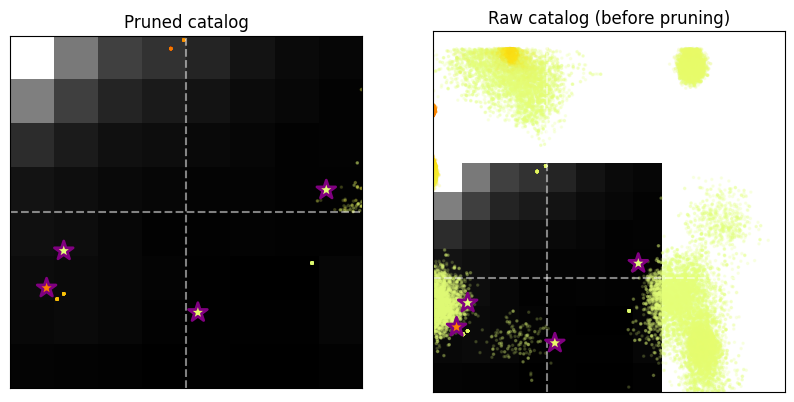

In [6]:
cb_locs = checkerboard.combined_locs.squeeze()      # [num_catalogs, max_sources, 2]
cb_fluxes = checkerboard.combined_fluxes.squeeze()  # [num_catalogs, max_sources]

# Filter to detected sources within the image bounds
mask = (
    (cb_fluxes > params["flux_detection_threshold"])
    & (cb_locs[..., 0] > 0) & (cb_locs[..., 0] < patch_dim)
    & (cb_locs[..., 1] > 0) & (cb_locs[..., 1] < patch_dim)
)
cb_counts = mask.sum(-1)

# Posterior count distribution
print(f"Posterior count distribution (ground truth: {n_true} stars):")
vals, cnts = cb_counts.unique(return_counts=True)
for v, c in zip(vals, cnts):
    print(f"  {v.int().item()} stars: {c.item() / num_catalogs:.3f}")

# Raw catalog (before pruning)
raw_locs = checkerboard.combined_raw_locs.squeeze()
raw_fluxes = checkerboard.combined_raw_fluxes.squeeze()
mask_raw = raw_fluxes > params["flux_detection_threshold"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

idx = torch.arange(num_catalogs)

# Left: pruned catalog
axes[0].imshow(patch.cpu(), cmap="gray")
axes[0].scatter(
    cb_locs[idx][mask[idx], 1].cpu() - 0.5,
    cb_locs[idx][mask[idx], 0].cpu() - 0.5,
    marker=".", cmap="Wistia", s=10, alpha=0.15,
    c=cb_fluxes[idx][mask[idx]].cpu(),
)
axes[0].set_title("Pruned catalog")

# Right: raw catalog
axes[1].imshow(patch.cpu(), cmap="gray")
axes[1].scatter(
    raw_locs[idx][mask_raw[idx], 1].cpu() - 0.5,
    raw_locs[idx][mask_raw[idx], 0].cpu() - 0.5,
    marker=".", cmap="Wistia", s=10, alpha=0.15,
    c=raw_fluxes[idx][mask_raw[idx]].cpu(),
)
axes[1].set_title("Raw catalog (before pruning)")

for ax in axes:
    ax.scatter(
        true_locs[:, 1].cpu() - 0.5,
        true_locs[:, 0].cpu() - 0.5,
        marker="*", cmap="Wistia", edgecolors="purple", linewidths=2,
        s=200, zorder=5, c=true_fluxes.cpu(),
    )
    ax.axhline(y=3.5, color="white", linestyle="--", alpha=0.5)
    ax.axvline(x=3.5, color="white", linestyle="--", alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])